# Notebook 03: Fixed Effects in Quantile Regression - Canay Two-Step

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the pure location shift assumption in quantile regression
2. Implement the Canay (2011) two-step estimator
3. Test the validity of the location shift assumption
4. Compare pooled QR vs Canay fixed effects QR
5. Interpret fixed effects in the quantile regression context
6. Understand when Canay method is appropriate vs when to use alternatives

## Duration
120 minutes

## Prerequisites
- Notebooks 01-02 (Quantile Regression Fundamentals and Multiple Quantiles)
- Understanding of fixed effects in OLS (within transformation)

## Dataset
Firm production panel: 500 firms over 10 years, with log output, capital, labor, and materials.
Simulated Cobb-Douglas production function with firm-specific productivity heterogeneity.

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries

# PanelBox imports
from panelbox.core.panel_data import PanelData
from panelbox.models.quantile import CanayTwoStep, PooledQuantile
from panelbox.models.static import FixedEffects

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Research Question

> *"Do firm-specific productivity differences affect all output quantiles equally, or do they have heterogeneous effects?"*

In standard OLS fixed effects regression, we control for unobserved entity-specific heterogeneity $\alpha_i$ via the within transformation. But in **quantile regression**, the relationship between fixed effects and the outcome can be more nuanced.

### Two Approaches to Fixed Effects in QR

| Approach | Model | Assumption | Method |
|----------|-------|------------|--------|
| **Location Shift** | $Q_\tau(Y_{it} \mid X_{it}, \alpha_i) = \alpha_i + X_{it}'\beta(\tau)$ | $\alpha_i$ same across all $\tau$ | Canay (2011) |
| **General** | $Q_\tau(Y_{it} \mid X_{it}, \alpha_i) = \alpha_i(\tau) + X_{it}'\beta(\tau)$ | $\alpha_i(\tau)$ varies with $\tau$ | Penalty method (Notebook 04) |

The **Canay two-step estimator** assumes the simpler location shift model. This is computationally efficient and easy to implement, but the location shift assumption is restrictive and must be tested.

> **Key Insight**  
> In OLS, the within transformation removes $\alpha_i$ cleanly because $E[Y_{it}|X_{it},\alpha_i] = \alpha_i + X_{it}'\beta$. In QR, the within transformation does **not** work directly because quantiles are not linear operators: $Q_\tau(Y - \bar{Y}) \neq Q_\tau(Y) - \bar{Y}$ in general. The Canay method sidesteps this by estimating $\alpha_i$ from OLS and then removing it before running QR.

---

## 2. Theoretical Concepts

### 2.1 Location Shift Model

The location shift model assumes:

$$Q_\tau(Y_{it} \mid X_{it}, \alpha_i) = \alpha_i + X_{it}'\beta(\tau)$$

**Key Properties:**
- $\alpha_i$: Individual fixed effect (time-invariant **and** $\tau$-invariant)
- $\beta(\tau)$: Slope coefficients (vary freely with $\tau$)
- The fixed effect shifts **all** quantiles by the same amount

**When is this reasonable?**
- Firm productivity that uniformly shifts the output distribution
- Ability effects that raise all wage quantiles equally
- Regional effects that shift price distributions

**When does it fail?**
- Risk-type heterogeneity (affects variance, not just location)
- Ability that interacts with quantile position (e.g., high-ability workers benefit more from shocks)

### 2.2 Canay Two-Step Procedure

**Step 1: Estimate fixed effects via FE-OLS**

Apply the within transformation and estimate by OLS:

$$\hat{\beta}_{OLS} = \left(\tilde{X}'\tilde{X}\right)^{-1} \tilde{X}'\tilde{Y}$$

where $\tilde{Y}_{it} = Y_{it} - \bar{Y}_i$ and $\tilde{X}_{it} = X_{it} - \bar{X}_i$.

Recover fixed effects:

$$\hat{\alpha}_i = \bar{Y}_i - \bar{X}_i'\hat{\beta}_{OLS}$$

**Step 2: Quantile regression on transformed outcome**

Transform the dependent variable by removing estimated fixed effects:

$$\tilde{Y}_{it} = Y_{it} - \hat{\alpha}_i$$

Run **pooled** quantile regression on the transformed data:

$$\hat{\beta}(\tau) = \arg\min_b \sum_{i,t} \rho_\tau(\tilde{Y}_{it} - X_{it}'b)$$

**Why it works:** Under location shift, $\tilde{Y}_{it} \approx Y_{it} - \alpha_i$, so $Q_\tau(\tilde{Y}_{it}|X_{it}) = X_{it}'\beta(\tau)$, which is a standard pooled QR.

### 2.3 Testing the Location Shift Assumption

The key assumption is testable. Under location shift, the slope coefficients $\beta(\tau)$ should be the same regardless of whether we estimate them with the Canay method.

**Wald Test:**

$$H_0: \beta(\tau_1) = \beta(\tau_2) = \cdots = \beta(\tau_m)$$
$$H_1: \text{At least one } \beta(\tau_j) \text{ differs}$$

A rejection of $H_0$ suggests that the location shift assumption is too restrictive and the penalty method (Notebook 04) should be preferred.

---

## 3. Implementation

### 3.1 Data Setup

In [2]:
# Load firm production data
data = pd.read_csv(DATA_DIR / "firm_production.csv")

# Panel structure
print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"Firms: {data['firm_id'].nunique()}")
print(f"Time periods: {data['year'].nunique()}")
print(f"Observations: {len(data)}")

print("\nDescriptive Statistics:")
display(data[["log_output", "log_capital", "log_labor", "log_materials"]].describe())

Dataset shape: (5000, 10)
Variables: ['firm_id', 'year', 'log_output', 'log_capital', 'log_labor', 'log_materials', 'profit', 'size', 'sector', 'exporter']
Firms: 500
Time periods: 10
Observations: 5000

Descriptive Statistics:


,log_output,log_capital,log_labor,log_materials
count,5000.0000,5000.0000,5000.0000,5000.0000
mean,5.7886,7.1462,4.9329,7.5015
std,0.9362,1.4983,1.2044,1.2979
min,2.8676,2.2022,1.4815,3.1410
25%,5.1794,6.1328,4.1235,6.6548
50%,5.7697,7.1876,4.9136,7.5325
75%,6.3913,8.1388,5.7671,8.3460
max,9.6562,11.2167,8.5783,11.2786


In [3]:
# Create PanelData object
panel = PanelData(data, entity_col="firm_id", time_col="year")
print(panel.summary())

# Formula for production function
formula = "log_output ~ log_capital + log_labor + log_materials"

PANEL DATA SUMMARY
Entity identifier: firm_id
Time identifier:   year
------------------------------------------------------------
Number of entities:     500
Number of time periods: 10
Total observations:     5,000
------------------------------------------------------------
Balanced:               Yes
Periods per entity:     10
------------------------------------------------------------
Time period range:      2010 to 2019


### 3.2 Baseline: FE-OLS

Before quantile regression, let's estimate the standard fixed effects OLS as a baseline. This gives us the within-group estimates of the production function coefficients.

In [4]:
# Fixed Effects OLS
fe_ols = FixedEffects(formula, data, entity_col="firm_id", time_col="year")
fe_ols_result = fe_ols.fit(cov_type="clustered")

print("=" * 60)
print("FIXED EFFECTS OLS RESULTS")
print("=" * 60)
print(fe_ols_result.summary())

print("\nCoefficients (elasticities):")
for var in ["log_capital", "log_labor", "log_materials"]:
    coef = fe_ols_result.params[var]
    se = fe_ols_result.std_errors[var]
    print(f"  {var:20s}: {coef:.4f} ({se:.4f})")

rts = sum(fe_ols_result.params[v] for v in ["log_capital", "log_labor", "log_materials"])
print(f"\n  Returns to scale: {rts:.4f}")

FIXED EFFECTS OLS RESULTS
                       Fixed Effects Estimation Results                       
Formula: log_output ~ log_capital + log_labor + log_materials
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:               5,000
No. Entities:                     500
No. Time Periods:                  10
Degrees of Freedom:             4,497
R-squared:                     0.0998
Adj. R-squared:               -0.0007
R-squared (within):            0.0998
R-squared (between):           1.0000
R-squared (overall):           0.9070
Standard Errors:            clustered
F-statistic (FE vs OLS):      29.7160
F-test p-value:                0.0000
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
log_capital          0.3036      0.0225  13.474  0.0000    0.2594    0.3477 ***
log_labor            0.3656      0

### 3.3 Baseline: Pooled QR (No Fixed Effects)

Pooled quantile regression ignores the panel structure entirely. It treats all observations as independent, which can lead to omitted variable bias if unobserved heterogeneity is correlated with the regressors.

In [5]:
# Prepare arrays for PooledQuantile
y = data["log_output"].values
var_names_qr = ["const", "log_capital", "log_labor", "log_materials"]
X = np.column_stack(
    [
        np.ones(len(data)),
        data["log_capital"].values,
        data["log_labor"].values,
        data["log_materials"].values,
    ]
)
entity_id = data["firm_id"].values

# Estimate pooled QR at multiple quantiles
tau_list = [0.1, 0.25, 0.5, 0.75, 0.9]
pooled_results = {}

print("Estimating Pooled QR (no fixed effects)...")
for tau in tau_list:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    pooled_results[tau] = model.fit(se_type="cluster")

print("\n" + "=" * 70)
print("POOLED QUANTILE REGRESSION (No Fixed Effects)")
print("=" * 70)
print(f"{'Variable':<18}", end="")
for tau in tau_list:
    print(f"{'τ=' + str(tau):>12}", end="")
print()
print("-" * 78)

for i, var in enumerate(var_names_qr):
    print(f"{var:<18}", end="")
    for tau in tau_list:
        coef = pooled_results[tau].params.ravel()[i]
        print(f"{coef:12.4f}", end="")
    print()

Estimating Pooled QR (no fixed effects)...

POOLED QUANTILE REGRESSION (No Fixed Effects)
Variable                 τ=0.1      τ=0.25       τ=0.5      τ=0.75       τ=0.9
------------------------------------------------------------------------------
const                  -0.5226     -0.0664      0.1440      0.4028      0.6250
log_capital             0.3020      0.2997      0.3046      0.3095      0.3035
log_labor               0.3517      0.3444      0.3600      0.3694      0.3888
log_materials           0.2210      0.2150      0.2256      0.2351      0.2451


### 3.4 Canay Two-Step Estimator

Now we use the Canay (2011) two-step estimator to control for firm-specific fixed effects while estimating quantile-varying coefficients.

In [6]:
# Canay Two-Step estimation
canay_results = {}

print("Estimating Canay Two-Step FE-QR...")
for tau in tau_list:
    canay_model = CanayTwoStep(panel, formula=formula, tau=tau)
    canay_results[tau] = canay_model.fit(verbose=False)

# Display results
print("\n" + "=" * 70)
print("CANAY TWO-STEP FE QUANTILE REGRESSION")
print("=" * 70)

# Variable names from formula (Canay includes constant)
canay_var_names = ["const", "log_capital", "log_labor", "log_materials"]

print(f"{'Variable':<18}", end="")
for tau in tau_list:
    print(f"{'τ=' + str(tau):>12}", end="")
print()
print("-" * 78)

for i, var in enumerate(canay_var_names):
    print(f"{var:<18}", end="")
    for tau in tau_list:
        coef = canay_results[tau].results[tau].params[i]
        print(f"{coef:12.4f}", end="")
    print()

print("\nStandard Errors:")
for i, var in enumerate(canay_var_names):
    print(f"{var:<18}", end="")
    for tau in tau_list:
        se = canay_results[tau].results[tau].bse[i]
        print(f"{se:12.4f}", end="")
    print()

Estimating Canay Two-Step FE-QR...



CANAY TWO-STEP FE QUANTILE REGRESSION
Variable                 τ=0.1      τ=0.25       τ=0.5      τ=0.75       τ=0.9
------------------------------------------------------------------------------
const                  -0.3257     -0.1388      0.0165      0.1608      0.3368
log_capital             0.3023      0.3000      0.3028      0.3049      0.3032
log_labor               0.3699      0.3657      0.3616      0.3637      0.3707
log_materials           0.2784      0.2805      0.2855      0.2891      0.2872

Standard Errors:
const                   0.0940      0.1223      0.1377      0.1205      0.0911
log_capital             0.0077      0.0100      0.0113      0.0098      0.0075
log_labor               0.0095      0.0124      0.0140      0.0122      0.0092
log_materials           0.0089      0.0115      0.0130      0.0114      0.0086


In [7]:
# Show detailed summary for the median
print("Detailed summary for τ = 0.5:")
canay_results[0.5].summary(tau=0.5)

Detailed summary for τ = 0.5:

CANAY TWO-STEP QUANTILE REGRESSION RESULTS

Step 1: Fixed Effects (OLS)
----------------------------------------
Number of entities: 500
Mean FE:  -0.3210
Std FE:    0.5236
Min FE:   -1.7767
Max FE:    1.2027

Step 2: Quantile Regression on Transformed Data
----------------------------------------

τ = 0.5
  Coefficients:
    β1:   0.0165 (0.1377)  t=  0.12
    β2:   0.3028 (0.0113)  t= 26.86
    β3:   0.3616 (0.0140)  t= 25.89
    β4:   0.2855 (0.0130)  t= 21.97


### 3.5 Comparison: Pooled QR vs Canay FE-QR

Let's compare the coefficient paths from pooled QR and Canay FE-QR. Differences between the two indicate the presence of unobserved heterogeneity that the pooled model ignores.

In [8]:
# Comparison table
print("=" * 80)
print("COMPARISON: POOLED QR vs CANAY FE-QR")
print("=" * 80)

comparison_rows = []
for tau in tau_list:
    for i, var in enumerate(["log_capital", "log_labor", "log_materials"]):
        pooled_coef = pooled_results[tau].params.ravel()[i + 1]  # skip const
        canay_coef = canay_results[tau].results[tau].params[i + 1]  # skip const
        diff = canay_coef - pooled_coef
        comparison_rows.append(
            {
                "tau": tau,
                "variable": var,
                "pooled": pooled_coef,
                "canay": canay_coef,
                "difference": diff,
            }
        )

comp_df = pd.DataFrame(comparison_rows)
comp_pivot = comp_df.pivot_table(
    index="variable", columns="tau", values=["pooled", "canay", "difference"]
)
display(
    comp_df.pivot_table(index=["variable", "tau"], values=["pooled", "canay", "difference"]).round(
        4
    )
)

COMPARISON: POOLED QR vs CANAY FE-QR


canay  difference  pooled
variable      tau                             
log_capital   0.10  0.3023      0.0003  0.3020
              0.25  0.3000      0.0002  0.2997
              0.50  0.3028     -0.0018  0.3046
              0.75  0.3049     -0.0046  0.3095
              0.90  0.3032     -0.0003  0.3035
log_labor     0.10  0.3699      0.0181  0.3517
              0.25  0.3657      0.0213  0.3444
              0.50  0.3616      0.0016  0.3600
              0.75  0.3637     -0.0057  0.3694
              0.90  0.3707     -0.0180  0.3888
log_materials 0.10  0.2784      0.0575  0.2210
              0.25  0.2805      0.0656  0.2150
              0.50  0.2855      0.0599  0.2256
              0.75  0.2891      0.0540  0.2351
              0.90  0.2872      0.0421  0.2451

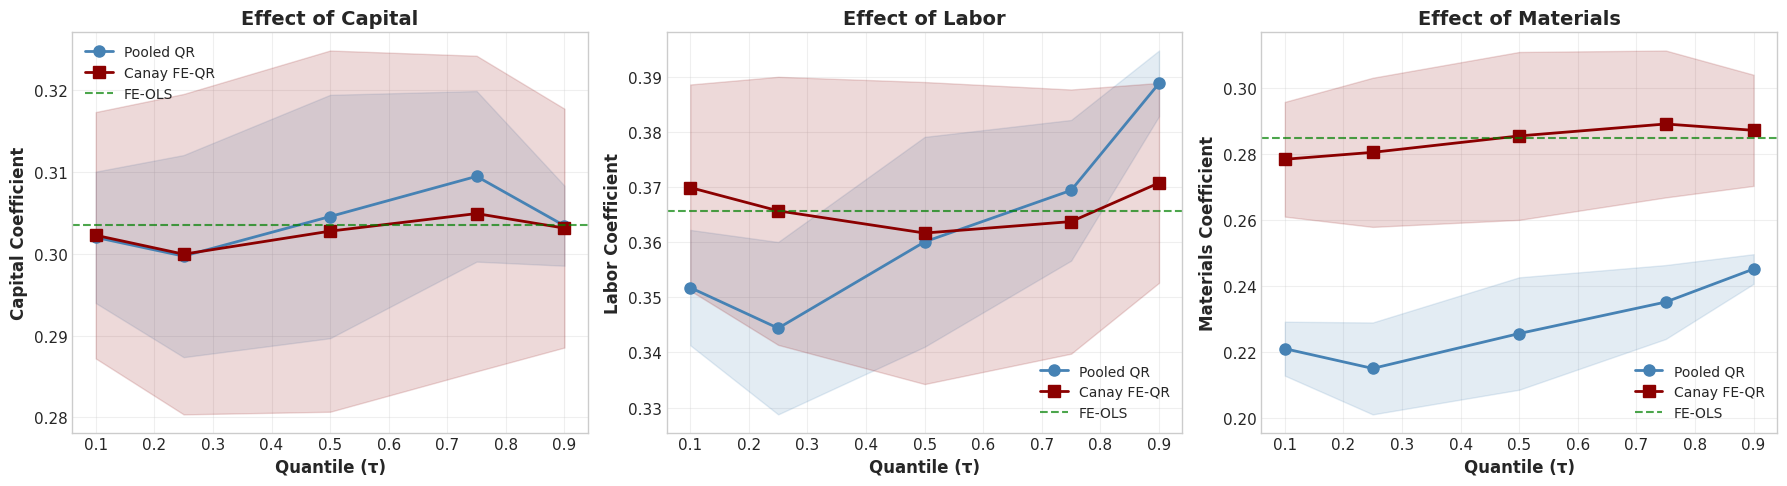

Plot saved to outputs/plots/03_pooled_vs_canay.png


In [9]:
# Comparison plot: Pooled vs Canay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = ["log_capital", "log_labor", "log_materials"]
labels = ["Capital", "Labor", "Materials"]

for idx, (var, label) in enumerate(zip(variables, labels)):
    var_idx = variables.index(var) + 1  # +1 to skip constant

    # Pooled coefficients
    pooled_coefs = [pooled_results[tau].params.ravel()[var_idx] for tau in tau_list]
    pooled_ses = [pooled_results[tau].std_errors.ravel()[var_idx] for tau in tau_list]

    # Canay coefficients
    canay_coefs = [canay_results[tau].results[tau].params[var_idx] for tau in tau_list]
    canay_ses = [canay_results[tau].results[tau].bse[var_idx] for tau in tau_list]

    # FE-OLS reference
    fe_ols_coef = fe_ols_result.params[var]

    # Plot
    axes[idx].plot(
        tau_list,
        pooled_coefs,
        "o-",
        label="Pooled QR",
        linewidth=2,
        markersize=8,
        color="steelblue",
    )
    axes[idx].fill_between(
        tau_list,
        np.array(pooled_coefs) - 1.96 * np.array(pooled_ses),
        np.array(pooled_coefs) + 1.96 * np.array(pooled_ses),
        alpha=0.15,
        color="steelblue",
    )

    axes[idx].plot(
        tau_list, canay_coefs, "s-", label="Canay FE-QR", linewidth=2, markersize=8, color="darkred"
    )
    axes[idx].fill_between(
        tau_list,
        np.array(canay_coefs) - 1.96 * np.array(canay_ses),
        np.array(canay_coefs) + 1.96 * np.array(canay_ses),
        alpha=0.15,
        color="darkred",
    )

    axes[idx].axhline(
        fe_ols_coef, color="green", linestyle="--", linewidth=1.5, label="FE-OLS", alpha=0.7
    )

    axes[idx].set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel(f"{label} Coefficient", fontsize=12, fontweight="bold")
    axes[idx].set_title(f"Effect of {label}", fontsize=14, fontweight="bold")
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_pooled_vs_canay.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/plots/03_pooled_vs_canay.png")

*Figure: Comparison of coefficient paths from Pooled QR (blue) and Canay FE-QR (red) across quantiles. The green dashed line shows the FE-OLS estimate. Differences between pooled and Canay estimates reveal the bias from ignoring unobserved heterogeneity.*

> **Reading the Comparison**  
> If pooled and Canay estimates diverge substantially, unobserved heterogeneity is important. The Canay estimates are preferred when the location shift assumption holds, as they control for firm-specific productivity differences.

### 3.6 Location Shift Test

Before relying on the Canay estimates, we should test whether the location shift assumption is valid. The test checks whether the slope coefficients vary significantly across quantiles — under location shift, the fixed effects are constant across $\tau$, but the slopes can still vary.

In [10]:
# Test location shift assumption
canay_test = CanayTwoStep(panel, formula=formula, tau=0.5)
canay_test.fit(verbose=False)

test_result = canay_test.test_location_shift(tau_grid=[0.1, 0.25, 0.5, 0.75, 0.9], method="wald")


Testing Location Shift Assumption
H0: Fixed effects are pure location shifters
Testing across quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
  Estimating τ = 0.1...
  Estimating τ = 0.25...
  Estimating τ = 0.5...
  Estimating τ = 0.75...
  Estimating τ = 0.9...



LOCATION SHIFT TEST RESULTS
H0: Fixed effects are pure location shifters
Method: wald
Test Statistic: 7620.5871
Degrees of Freedom: 16
P-value: 0.0000

Conclusion: REJECT H0 at 5% level
Fixed effects appear to vary across quantiles.
Canay estimator may be biased. Consider penalty method.


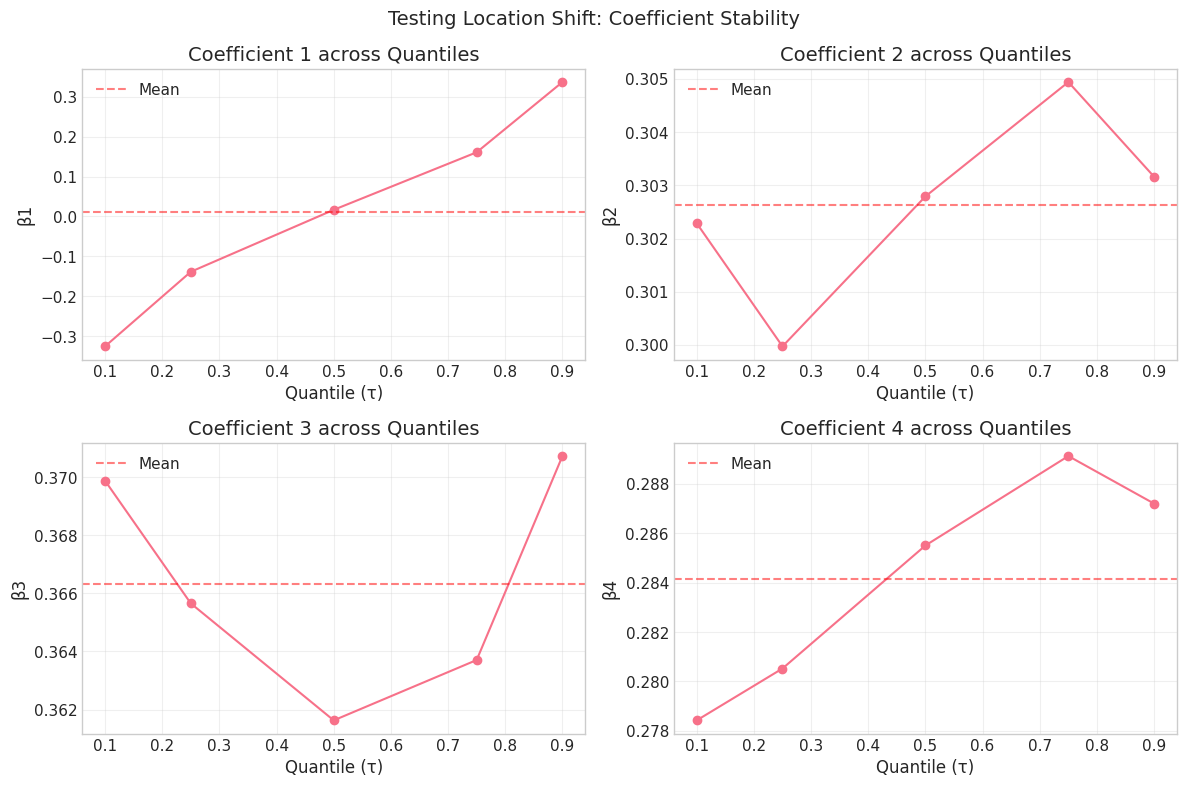

Test results saved to outputs/results/03_location_shift_test.csv


In [11]:
# Visualize coefficient variation across quantiles
fig = test_result.plot_coefficient_variation()
plt.show()

# Save test results
test_df = pd.DataFrame(
    {
        "statistic": [test_result.statistic],
        "p_value": [test_result.p_value],
        "df": [test_result.df],
        "method": [test_result.method],
        "tau_grid": [str(test_result.tau_grid)],
        "conclusion": ["Reject H0" if test_result.p_value < 0.05 else "Cannot reject H0"],
    }
)
test_df.to_csv(RESULTS_DIR / "03_location_shift_test.csv", index=False)
print("Test results saved to outputs/results/03_location_shift_test.csv")

> **Interpreting the Location Shift Test**  
> - **Cannot reject H0**: Location shift is reasonable. Canay method is appropriate.
> - **Reject H0**: Location shift is too restrictive. Consider the penalty method (Notebook 04).
>
> Note: The Wald test can be conservative (over-reject) with many quantiles due to accumulated estimation error. Use the test as guidance, not a definitive answer.

---

## 4. Case Study: Firm Productivity Distribution

### 4.1 Distribution of Estimated Fixed Effects

The estimated fixed effects $\hat{\alpha}_i$ represent firm-specific productivity levels. Their distribution reveals the extent of productivity heterogeneity in the sample.

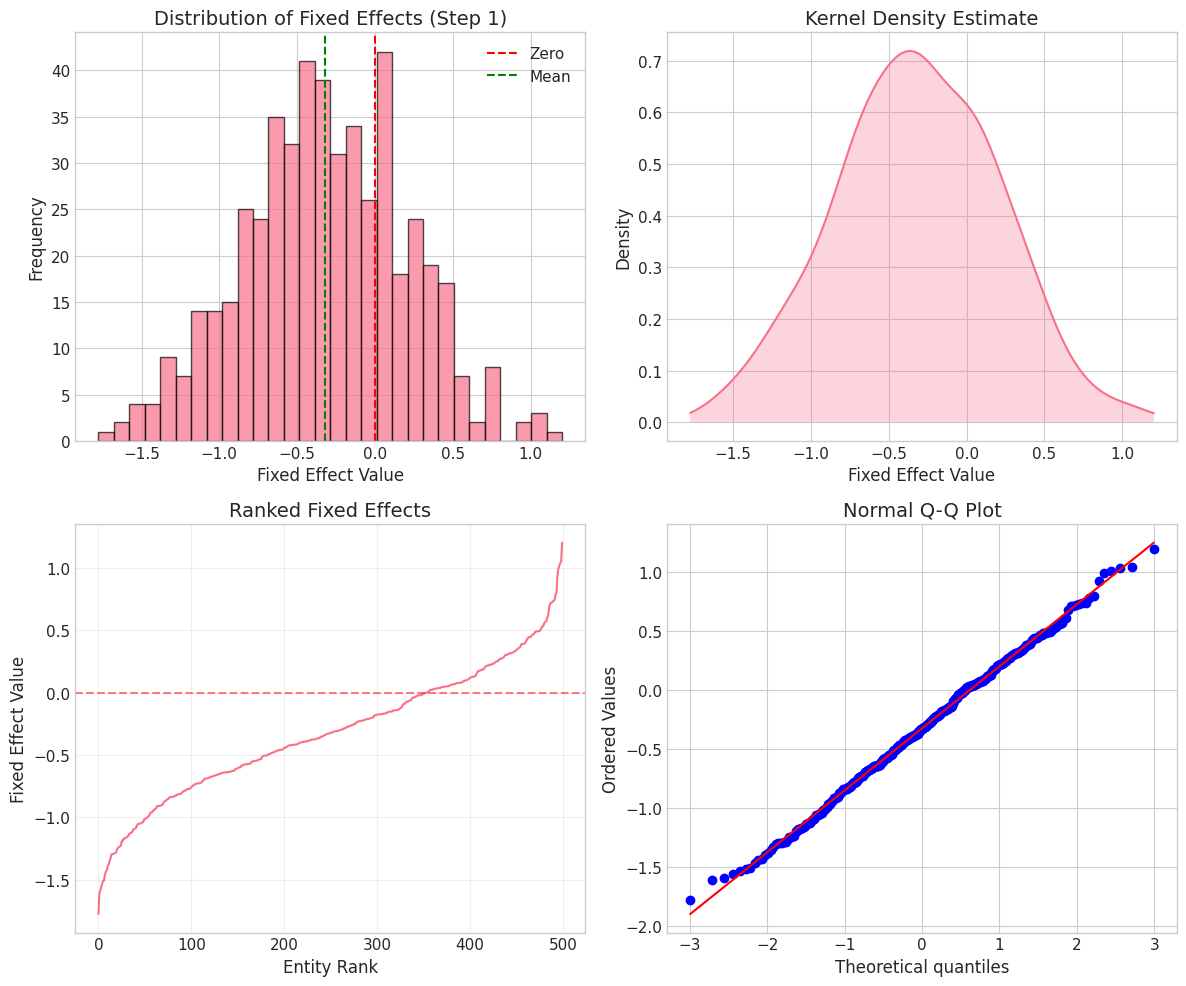

Plot saved to outputs/plots/03_fe_distribution.png

Fixed Effects Summary:
  N firms:  500
  Mean:     -0.3210
  Std:      0.5236
  Min:      -1.7767
  Max:      1.2027
  IQR:      0.7158


In [12]:
# Get fixed effects from the Canay result (any tau gives the same FE)
fixed_effects = canay_results[0.5].fixed_effects

# Plot FE distribution
fig = canay_results[0.5].plot_fixed_effects_distribution()
plt.savefig(PLOTS_DIR / "03_fe_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/plots/03_fe_distribution.png")
print("\nFixed Effects Summary:")
print(f"  N firms:  {len(fixed_effects)}")
print(f"  Mean:     {np.mean(fixed_effects):.4f}")
print(f"  Std:      {np.std(fixed_effects):.4f}")
print(f"  Min:      {np.min(fixed_effects):.4f}")
print(f"  Max:      {np.max(fixed_effects):.4f}")
print(f"  IQR:      {np.percentile(fixed_effects, 75) - np.percentile(fixed_effects, 25):.4f}")

*Figure: Distribution of estimated firm fixed effects from the Canay two-step procedure. Top-left: histogram. Top-right: kernel density estimate. Bottom-left: ranked fixed effects showing the spread of firm productivity. Bottom-right: Q-Q plot assessing normality of the FE distribution.*

### 4.2 Interpreting Heterogeneous Effects

The Canay estimates tell us how factor inputs affect output differently across the output distribution, **conditional on removing firm-specific productivity**.

In [13]:
# Detailed interpretation
print("=" * 70)
print("INTERPRETING CANAY RESULTS: PRODUCTION FUNCTION HETEROGENEITY")
print("=" * 70)

for var, label in zip(
    ["log_capital", "log_labor", "log_materials"], ["Capital", "Labor", "Materials"]
):
    var_idx = ["const", "log_capital", "log_labor", "log_materials"].index(var)

    coefs = {tau: canay_results[tau].results[tau].params[var_idx] for tau in tau_list}

    print(f"\n{label} Elasticity:")
    for tau in tau_list:
        coef = coefs[tau]
        # Interpretation: 10% increase in input -> coef% increase in output
        print(
            f"  \u03c4={tau}: \u03b2 = {coef:.4f} "
            f"(10% increase in {label.lower()} \u2192 {coef * 10:.2f}% increase in output)"
        )

    # Heterogeneity assessment
    spread = coefs[0.9] - coefs[0.1]
    print(f"  Spread (\u03c4=0.9 - \u03c4=0.1): {spread:.4f}")
    if abs(spread) > 0.05:
        direction = "higher" if spread > 0 else "lower"
        print(f"  \u2192 {label} elasticity is {direction} at high-output quantiles")
    else:
        print(f"  \u2192 {label} elasticity is relatively homogeneous across quantiles")

INTERPRETING CANAY RESULTS: PRODUCTION FUNCTION HETEROGENEITY

Capital Elasticity:
  τ=0.1: β = 0.3023 (10% increase in capital → 3.02% increase in output)
  τ=0.25: β = 0.3000 (10% increase in capital → 3.00% increase in output)
  τ=0.5: β = 0.3028 (10% increase in capital → 3.03% increase in output)
  τ=0.75: β = 0.3049 (10% increase in capital → 3.05% increase in output)
  τ=0.9: β = 0.3032 (10% increase in capital → 3.03% increase in output)
  Spread (τ=0.9 - τ=0.1): 0.0009
  → Capital elasticity is relatively homogeneous across quantiles

Labor Elasticity:
  τ=0.1: β = 0.3699 (10% increase in labor → 3.70% increase in output)
  τ=0.25: β = 0.3657 (10% increase in labor → 3.66% increase in output)
  τ=0.5: β = 0.3616 (10% increase in labor → 3.62% increase in output)
  τ=0.75: β = 0.3637 (10% increase in labor → 3.64% increase in output)
  τ=0.9: β = 0.3707 (10% increase in labor → 3.71% increase in output)
  Spread (τ=0.9 - τ=0.1): 0.0008
  → Labor elasticity is relatively homogen

In [14]:
# Returns to scale across quantiles
print("\n" + "=" * 60)
print("RETURNS TO SCALE ACROSS QUANTILES")
print("=" * 60)

rts_data = []
for tau in tau_list:
    params = canay_results[tau].results[tau].params
    # Sum of capital, labor, and materials elasticities (skip constant)
    rts = params[1] + params[2] + params[3]
    rts_data.append({"tau": tau, "returns_to_scale": rts})
    scale_type = "increasing" if rts > 1.05 else ("decreasing" if rts < 0.95 else "constant")
    print(f"  \u03c4={tau}: RTS = {rts:.4f} ({scale_type})")

# FE-OLS for comparison
rts_ols = sum(fe_ols_result.params[v] for v in ["log_capital", "log_labor", "log_materials"])
print(f"\n  FE-OLS: RTS = {rts_ols:.4f}")

rts_df = pd.DataFrame(rts_data)
rts_df.to_csv(RESULTS_DIR / "03_returns_to_scale.csv", index=False)
print("\nReturns to scale saved to outputs/results/03_returns_to_scale.csv")


RETURNS TO SCALE ACROSS QUANTILES
  τ=0.1: RTS = 0.9506 (constant)
  τ=0.25: RTS = 0.9461 (decreasing)
  τ=0.5: RTS = 0.9499 (decreasing)
  τ=0.75: RTS = 0.9578 (constant)
  τ=0.9: RTS = 0.9611 (constant)

  FE-OLS: RTS = 0.9540

Returns to scale saved to outputs/results/03_returns_to_scale.csv


---

## 5. When to Use Canay vs Alternatives

### Decision Framework

| Criterion | Canay Two-Step | Penalty Method (Notebook 04) |
|-----------|---------------|------------------------------|
| **Assumption** | Location shift ($\alpha_i$ constant across $\tau$) | General FE ($\alpha_i(\tau)$ varies) |
| **Panel length** | Requires large T (consistency) | Works with small T |
| **Speed** | Very fast (OLS + pooled QR) | Slower (optimization with penalty) |
| **Tuning** | None | Penalty parameter $\lambda$ |
| **When to use** | Location shift test passes; T is large | Location shift rejected; short panels |

### Practical Decision Tree

```
Panel data with unobserved heterogeneity?
  |
  +-- Test location shift assumption
  |     |
  |     +-- PASS --> Use Canay (efficient, simple)
  |     |
  |     +-- FAIL --> Use penalty method (Notebook 04)
  |
  +-- Short panel (T <= 5) --> Consider penalty method
  |
  +-- No panel structure --> Use pooled QR (Notebooks 01-02)
```

### Key Takeaways

1. **Location shift is testable** — always test before using Canay
2. **Canay is fast** — computationally equivalent to one OLS + one QR per quantile
3. **FE-OLS captures the "average" effect** — Canay reveals heterogeneity beyond the mean
4. **Standard errors must account for two-step estimation** — naive SEs understate uncertainty

---

## 6. Summary and Key Takeaways

1. **Fixed effects in QR** require special treatment because quantiles are not linear operators — the within transformation does not work directly.

2. **Location shift assumption**: $\alpha_i$ is the same across all quantiles. This means the fixed effect shifts the entire conditional distribution uniformly.

3. **Canay two-step**: (i) Estimate $\hat{\alpha}_i$ from FE-OLS, (ii) run pooled QR on $Y_{it} - \hat{\alpha}_i$. Simple, fast, and effective when the assumption holds.

4. **Location shift test**: Always test the assumption using the Wald test before relying on Canay estimates.

5. **Controlling for FE changes inference**: Comparing pooled QR vs Canay FE-QR reveals the importance of unobserved heterogeneity.

### References

1. **Canay, I. A. (2011)**. "A Simple Approach to Quantile Regression for Panel Data". *Econometrics Journal*, 14(3), 368-386.
2. **Koenker, R. (2004)**. "Quantile Regression for Longitudinal Data". *Journal of Multivariate Analysis*, 91(1), 74-89.
3. **Galvao, A. F., & Wang, L. (2015)**. "Efficient Minimum Distance Estimator for Quantile Regression Fixed Effects Panel Data". *Journal of Multivariate Analysis*, 133, 1-26.

### Next Steps

In **Notebook 04**, we will explore the **Penalty Fixed Effects Method** (Koenker 2004), which allows $\alpha_i(\tau)$ to vary with $\tau$ and works well even with short panels.

---

## Exercises

### Exercise 1: Conceptual Understanding (Easy)

**Question**: Why can't we use the within transformation (demeaning) directly in quantile regression like we do in OLS?

**Hint**: Think about what happens to quantiles when you subtract the group mean. Does $Q_\tau(Y - \bar{Y}) = Q_\tau(Y) - \bar{Y}$?

In [15]:
# Exercise 1: Write your answer as comments

# Why the within transformation fails for QR:
#
#
# The key mathematical property:
#
#

### Exercise 2: Manual Canay Two-Step (Easy)

**Task**: Implement the Canay two-step procedure manually (without using the `CanayTwoStep` class). Use `FixedEffects` for step 1 and `PooledQuantile` for step 2.

**Steps**:
1. Fit FE-OLS to get $\hat{\beta}_{OLS}$
2. Compute fixed effects $\hat{\alpha}_i = \bar{Y}_i - \bar{X}_i'\hat{\beta}_{OLS}$
3. Transform: $\tilde{Y}_{it} = Y_{it} - \hat{\alpha}_i$
4. Run pooled QR on $\tilde{Y}_{it}$
5. Compare with the `CanayTwoStep` class results

In [16]:
# Exercise 2: Manual Canay two-step

# Step 1: FE-OLS
# TODO: Fit FixedEffects OLS and get residuals

# Step 2: Recover fixed effects
# TODO: Compute alpha_hat_i = mean(Y_i) - mean(X_i) @ beta_hat

# Step 3: Transform Y
# TODO: Y_tilde = Y - alpha_hat_i

# Step 4: Pooled QR on transformed Y
# TODO: Fit PooledQuantile with Y_tilde

# Step 5: Compare
# TODO: Compare manual vs CanayTwoStep results


### Exercise 3: Location Shift Violation (Medium)

**Task**: Simulate data where the location shift assumption is violated (i.e., $\alpha_i(\tau)$ varies with $\tau$). Then estimate with Canay and show the resulting bias.

**Hint**: Load the `location_shift.csv` dataset which has two groups — one satisfying location shift and one violating it. Compare Canay estimates for each group.

In [17]:
# Exercise 3: Location shift violation

# TODO: Load location_shift.csv
# TODO: Separate 'shift' and 'no_shift' groups
# TODO: Estimate Canay for each group
# TODO: Compare with true coefficients (beta_x1=1.0, beta_x2=0.5)
# TODO: Show that bias is larger for the 'no_shift' group


### Exercise 4: Computational Time Comparison (Medium)

**Task**: Compare the computational time for Pooled QR, Canay FE-QR, and FE-OLS. Measure the time for estimating at 5 quantile levels.

**Hint**: Use `time.time()` to measure wall-clock time.

In [18]:
# Exercise 4: Timing comparison

# TODO: Time Pooled QR (5 quantiles)
# TODO: Time Canay FE-QR (5 quantiles)
# TODO: Time FE-OLS (single estimation)
# TODO: Create comparison table


### Exercise 5: Custom Location Shift Test (Hard)

**Task**: Implement your own location shift test based on the idea that if location shift holds, the estimated $\hat{\alpha}_i$ from separate Canay estimations at different $\tau$ should be the same.

**Procedure**:
1. For each $\tau \in \{0.1, 0.5, 0.9\}$, estimate Canay and recover $\hat{\alpha}_i(\tau)$
2. Under H0 (location shift), $\hat{\alpha}_i(0.1) \approx \hat{\alpha}_i(0.5) \approx \hat{\alpha}_i(0.9)$
3. Test by computing the correlation between $\hat{\alpha}_i(\tau)$ across $\tau$ values
4. A high correlation supports location shift; a low correlation suggests violation

**Hint**: Under location shift, the FE from step 1 are the same regardless of $\tau$ (since they come from OLS). But you can also estimate FE by running the median regression residuals vs. entity dummies.

In [19]:
# Exercise 5: Custom location shift test

# TODO: Estimate FE-OLS residuals
# TODO: For each tau, estimate pooled QR on residuals
# TODO: Compute entity-level quantile residuals
# TODO: Test if quantile-specific residuals are tau-invariant


### Exercise 6: Application - Worker Wage Dynamics (Hard)

**Task**: Use the Card education dataset (`card_education.csv`) to study wage dynamics controlling for worker fixed effects.

**Important**: For the Canay estimator, only **time-varying** regressors can be used. Variables like `educ`, `female`, and `black` are time-invariant and get absorbed by the fixed effects. Use `exper`, `married`, and `union` as regressors.

**Questions**:
1. Do returns to experience vary across wage quantiles after controlling for worker FE?
2. Is the union premium different with vs without FE controls?
3. Does the location shift assumption hold for this data?
4. Interpret the fixed effects distribution — what do they represent?

In [20]:
# Exercise 6: Worker wage dynamics

# TODO: Load card_education.csv
# TODO: Create PanelData object
# TODO: Estimate Pooled QR and Canay FE-QR for wage equation
# TODO: Compare education returns and gender gap
# TODO: Test location shift
# TODO: Interpret FE distribution
